#  Movie Data Analysis & Recommendation System

## Objective
Analyze movie data and build a recommendation system using NLP techniques.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

print("Environment Ready 🚀")

Environment Ready 🚀


## 1. Data Loading & Initial Exploration

In [7]:
df=pd.read_csv('movies.csv')
credits=pd.read_csv('credits.csv')
df_full = df.merge(credits, left_on='id', right_on='movie_id')
df_full.rename(columns={'title_x': 'title'}, inplace=True)
df_full.head()

FileNotFoundError: [Errno 2] No such file or directory: 'movies.csv'

## 2. Data Cleaning and Preprocessing

(array([6.300e+01, 1.000e+00, 2.000e+00, 1.000e+00, 1.000e+01, 1.100e+01,
        3.700e+01, 4.700e+01, 1.160e+02, 2.400e+02, 4.710e+02, 8.320e+02,
        1.025e+03, 9.590e+02, 6.510e+02, 2.520e+02, 7.700e+01, 2.000e+00,
        1.000e+00, 5.000e+00]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. ]),
 <BarContainer object of 20 artists>)

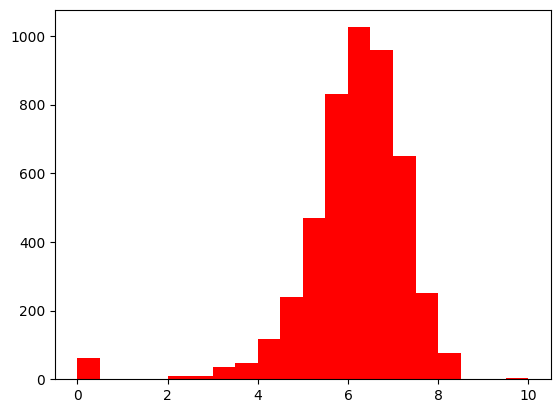

In [ ]:
df_full['genres'] = df_full['genres'].apply(ast.literal_eval)
df_full['production_companies'] = df_full['production_companies'].apply(ast.literal_eval)
df_full['crew'] = df_full['crew'].apply(ast.literal_eval)

df_full['genre_names'] = df_full['genres'].apply(lambda x: [i['name'] for i in x])
df_full['companies'] = df_full['production_companies'].apply(lambda x: [i['name'] for i in x])
df_full['director'] = df_full['crew'].apply(
    lambda x: next((i['name'] for i in x if i['job'] == 'Director'), "")
)

df_full['director'] = df_full['director'].apply(lambda x: x.replace(" ", ""))
df_full['genre_names'] = df_full['genre_names'].apply(lambda x: [i.replace(" ", "") for i in x])
df_full['overview'] = df_full['overview'].fillna("")
plt.hist(df['vote_average'], bins=20, color='red')

## 3. Exploratory Data Analysis

In [ ]:
filt_greater_than_zero=df[(df['budget']>0) & df['revenue']>0]
filt_greater_than_zero[['budget','revenue']].corr()

,budget,revenue
budget,1.000000,0.700085
revenue,0.700085,1.000000


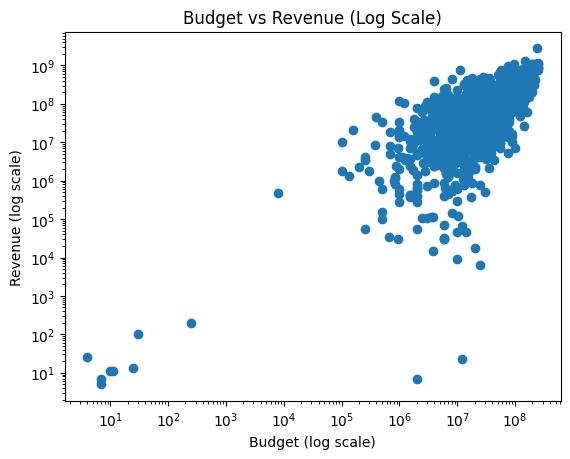

In [ ]:
plt.scatter(filt_greater_than_zero['budget'], filt_greater_than_zero['revenue'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Budget (log scale)")
plt.ylabel("Revenue (log scale)")
plt.title("Budget vs Revenue (Log Scale)")
plt.show()

## Budget vs Revenue Analysis

### Question
Does higher budget lead to higher revenue?

### Method
Filtered movies with budget and revenue > 0.
Computed Pearson correlation.
Visualized using scatter plot with log scaling.

### Result
Correlation ≈ 0.70

### Interpretation
Higher production budgets are associated with greater revenue, suggesting that investment increases earning potential.

In [ ]:
filt_greater_than_rating=df[(df['budget']>0) & df['vote_average']]
#filt_greater_than_rating
filt_greater_than_rating[['budget','vote_average']].corr()

,budget,vote_average
budget,1.00000,0.00365
vote_average,0.00365,1.00000


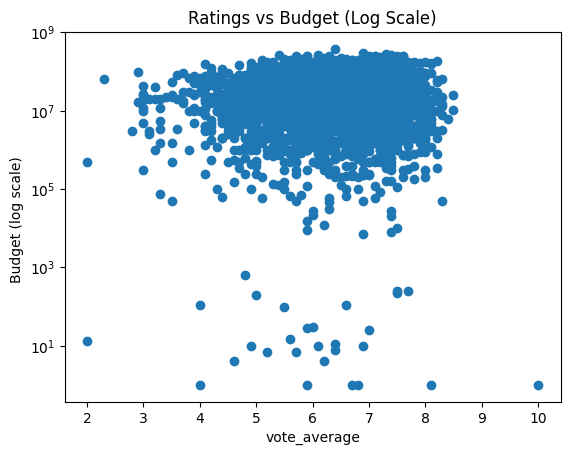

In [ ]:
plt.scatter(filt_greater_than_rating['vote_average'], filt_greater_than_rating['budget'])
plt.yscale('log')
plt.xlabel("vote_average")
plt.ylabel("Budget (log scale) ")
plt.title("Ratings vs Budget (Log Scale)")
plt.show()

## Budget vs Rating Analysis

### Question  
Does a higher production budget lead to better audience ratings?

### Method  
Filtered movies with budget > 0 and computed the correlation between `budget` and `vote_average`.  
Visualized the relationship using a scatter plot (log scale).

### Result  
Correlation ≈ 0.0036.

### Interpretation  
There is virtually very little relationship between production budget and audience rating.  
While higher budgets may increase box office revenue, they do not guarantee better reviews or overall film quality.

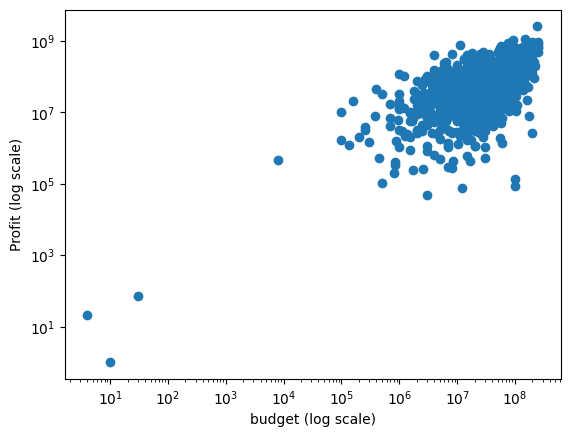

In [ ]:
filt_greater_than_zero['profit']=filt_greater_than_zero['revenue']-filt_greater_than_zero['budget']
plt.scatter(filt_greater_than_zero['budget'], filt_greater_than_zero['profit'])
plt.xscale('log')
plt.yscale('log')
filt_greater_than_zero[['profit','budget']].corr()
plt.xlabel("budget (log scale)")
plt.ylabel("Profit (log scale)")
plt.show()

## Budget vs Profit Analysis

### Result  
Correlation between budget and profit ≈ 0.54.

### Insight  
Higher budget films tend to generate greater absolute profits, but the relationship is moderate.  
While larger investments increase earning potential, they also involve greater financial risk and variability.

,roi,budget
roi,1.000000,-0.139116
budget,-0.139116,1.000000


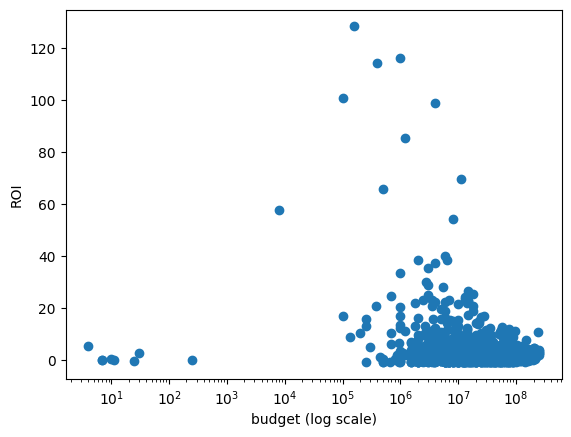

In [ ]:
filt_greater_than_zero['roi']=filt_greater_than_zero['profit']/filt_greater_than_zero['budget']
plt.scatter(filt_greater_than_zero['budget'], filt_greater_than_zero['roi'])
plt.xscale('log')
plt.xlabel("budget (log scale)")
plt.ylabel("ROI")
filt_greater_than_zero[['roi','budget']].corr()
#plt.show()

## Budget vs ROI Analysis

### Result  
Correlation between budget and ROI ≈ -0.14.

### Insight  
Higher budget films tend to generate larger absolute profits, but they are generally less efficient in terms of return on investment. Smaller budget films, while riskier, can produce significantly higher ROI when successful.

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Drama'),
  Text(1, 0, 'Comedy'),
  Text(2, 0, 'Thriller'),
  Text(3, 0, 'Action'),
  Text(4, 0, 'Romance'),
  Text(5, 0, 'Adventure'),
  Text(6, 0, 'Crime'),
  Text(7, 0, 'Science Fiction')])

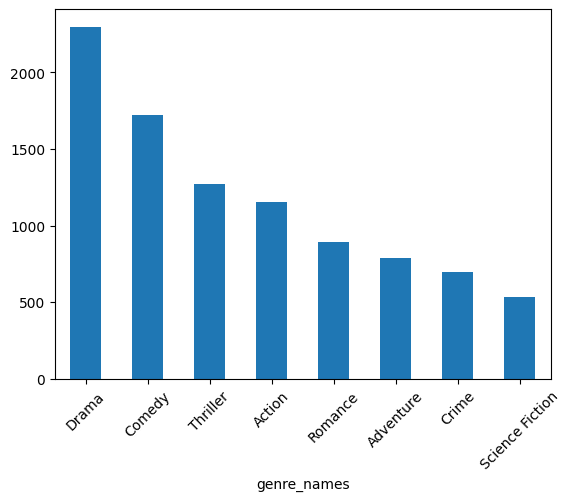

In [ ]:
df['genres']=df['genres'].apply(ast.literal_eval)
df['genre_names']=df['genres'].apply(lambda x:[i['name'] for i in x])
df_genres=df.explode('genre_names')
#df_genres[['title','genre_names']].head()
top_genres=df_genres['genre_names'].value_counts().head(8)
top_genres.plot(kind='bar')
plt.xticks(rotation=45)

(array([  0.,  50., 100., 150., 200., 250., 300., 350.]),
 [Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200'),
  Text(250.0, 0, '250'),
  Text(300.0, 0, '300'),
  Text(350.0, 0, '350')])

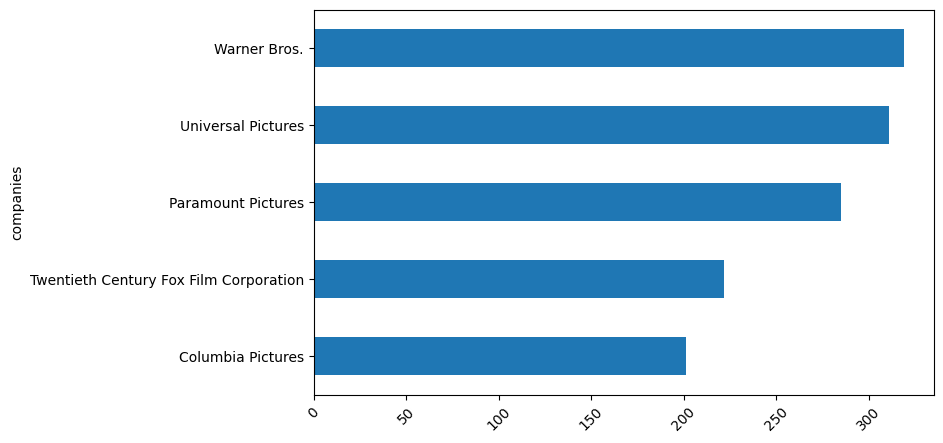

In [ ]:
df_companies=df_full.explode('companies')
#df_companies[['title','production_companies']].head()
top_companies=df_companies['companies'].value_counts().head(5)
plt.figure(figsize=(8,5))
top_companies.sort_values().plot(kind='barh')
#top_companies.plot(kind='bar')
plt.xticks(rotation=45)

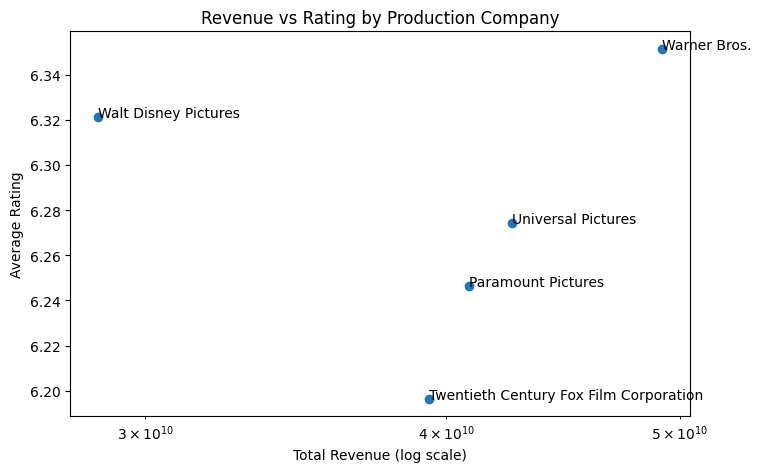

,revenue,vote_average
revenue,1.000000,0.042372
vote_average,0.042372,1.000000


In [ ]:
company_stats=df_companies.groupby("companies").agg({'revenue':'sum','vote_average':'mean',
                                                    'title':'count'})
company_stats.rename(columns={'title':'movie_count'},inplace=True)
company_stats=company_stats[company_stats['movie_count']>=5]
top20=company_stats.sort_values('revenue',ascending=False).head(5)
#company_stats.sort_values('vote_average',ascending=False)
plt.figure(figsize=(8,5))
plt.scatter(top20['revenue'], top20['vote_average'])
plt.xscale('log')
for company in top20.index:
    x = company_stats.loc[company, 'revenue']
    y = company_stats.loc[company, 'vote_average']
    plt.text(x, y, company)

plt.xlabel("Total Revenue (log scale)")
plt.ylabel("Average Rating")
plt.title("Revenue vs Rating by Production Company")
plt.show()
company_stats[['revenue','vote_average']].corr()


## Production Companies: Revenue vs Rating Analysis

### Revenue vs Rating Correlation

Correlation ≈ 0.04, indicating virtually no linear relationship between financial performance and audience ratings at the production company level.

### Observation  
When analyzing the top 5 revenue-generating production companies, we observe that although their total revenues differ significantly, their average ratings fall within a narrow range (~6.2–6.4).

### Insight  
Commercial dominance does not appear to translate into substantially higher audience ratings. Major studios such as Warner Bros., Walt Disney Pictures, and Universal Pictures operate at similar average rating levels despite large differences in total revenue.

### Additional Note  
When plotting all production companies together, the visualization appears highly clustered and noisy due to the large number of companies and relatively small variation in ratings. While this broader view provides a better overall industry picture, focusing on the top 5 companies allows for clearer comparison among major players.

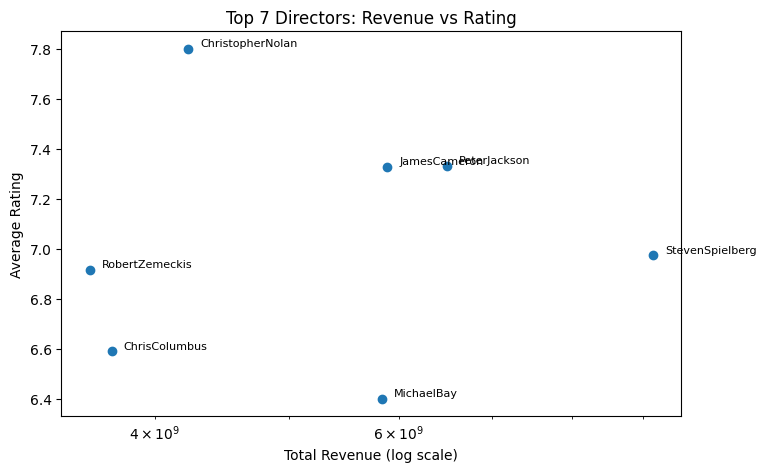

np.float64(0.2609475903396225)

In [ ]:
director_stats = df_full.groupby('director').agg({
    'revenue': 'sum',
    'vote_average': 'mean',
    'title': 'count'
}).rename(columns={'title': 'movie_count'})
director_stats = director_stats[director_stats['movie_count'] >= 5]
top_directors = director_stats.sort_values('revenue', ascending=False).head(7)
plt.figure(figsize=(8,5))
plt.scatter(top_directors['revenue'], top_directors['vote_average'])
plt.xscale('log')
for director in top_directors.index:
            x= top_directors.loc[director,'revenue']
            y= top_directors.loc[director,'vote_average']
            plt.text(x*1.02, y+0.01, director, fontsize=8)

plt.xlabel("Total Revenue (log scale)")
plt.ylabel("Average Rating")
plt.title("Top 7 Directors: Revenue vs Rating")
plt.show()
director_stats['revenue'].corr(director_stats['vote_average'])


## Director Analysis: Revenue vs Rating

### Observation  
Among top directors, Christopher Nolan stands out with the highest average ratings while maintaining strong revenue performance. Directors such as James Cameron and Steven Spielberg generate significantly higher total revenue but have slightly lower average ratings.

### Insight  
This indicates that while some directors consistently produce highly rated films, they may not always achieve the highest commercial success. Conversely, directors with massive box office earnings do not necessarily have the highest-rated films.

### Conclusion  
The correlation between revenue and rating for directors is relatively weak (≈ 0.24), suggesting that higher-rated films do not always translate into higher earnings.

## 4. Trend Analysis (Genres Over Time)

<Figure size 1000x500 with 0 Axes>

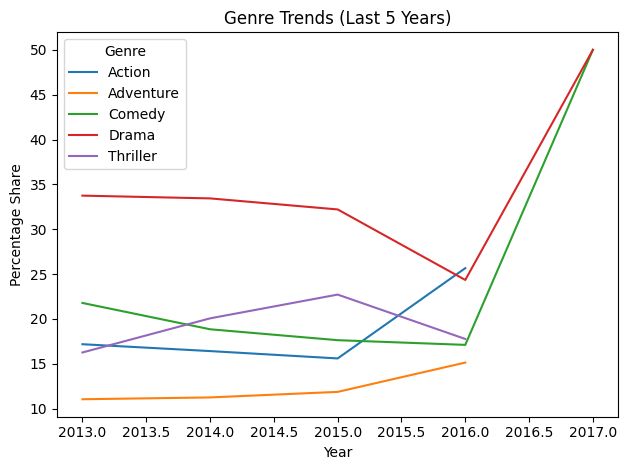

In [ ]:
df_full['release_date'] = pd.to_datetime(df_full['release_date'], errors='coerce')
df_full['year'] = df_full['release_date'].dt.year
df_genres = df_full.explode('genre_names')
max_year = df_full['year'].max()
df_genres_recent = df_genres[df_genres['year'] >= max_year - 4]
top_genres = df_genres_recent['genre_names'].value_counts().head(5).index
df_genres_recent = df_genres_recent[df_genres_recent['genre_names'].isin(top_genres)]
genre_counts = df_genres_recent.groupby(['year', 'genre_names']).size().reset_index(name='count')
total_per_year = genre_counts.groupby('year')['count'].transform('sum')
genre_counts['percentage'] = genre_counts['count'] / total_per_year * 100
pivot = genre_counts.pivot(index='year', columns='genre_names', values='percentage')
plt.figure(figsize=(10,5))
pivot.plot()
plt.title("Genre Trends (Last 5 Years)")
plt.xlabel("Year")
plt.ylabel("Percentage Share")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()

In [ ]:
df_full['director']=df_full['director'].apply(lambda x: x.replace(" ","") if isinstance(x,str) else "")
df_full['genre_names']=df_full['genre_names'].apply(lambda x: [i.replace(" ","") for i in x])
df_full['overview']=df_full['overview'].fillna("")
df_full['tags']=df_full['overview'] + " " + df_full['genre_names'].apply(lambda x: " ".join(x)) + " " + df_full['director']
df_full[['title', 'tags']].head()

,title,tags
0,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,Following the death of District Attorney Harve...
4,John Carter,"John Carter is a war-weary, former military ca..."


## 5. Recommendation System (Baseline - CountVectorizer)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
cv=CountVectorizer(max_features=5000, stop_words='english')
vectors_cv=cv.fit_transform(df_full['tags']).toarray()
similarity_cv=cosine_similarity(vectors_cv)
def recommend(movie):
    movie_index = df_full[df_full['title'] == movie].index[0]
    
    distances = similarity_cv[movie_index]
    
    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    for i in movie_list:
        print(df_full.iloc[i[0]].title)

NameError: name 'df_full' is not defined

## Conclusion

- Built a content-based recommendation system using CountVectorizer and cosine similarity.
- Observed that budget influences revenue but not ratings.
- Found weak correlation between commercial success and film quality.

### Future Improvements
- Use TF-IDF for better weighting
- Add keywords for improved recommendations
- Build a web interface (Streamlit)

## 6. Improved Recommendation System (TF-IDF + Keywords)

In [ ]:
df_full['keywords']=df_full['keywords'].apply(ast.literal_eval)
df_full['keyword_names'] = df_full['keywords'].apply(lambda x: [i['name'] for i in x])
df_full['keyword_names'] = df_full['keyword_names'].apply(lambda x: [i.replace(" ", "") for i in x])
df_full['tags'] = df_full['overview'] + " " + \
                  df_full['genre_names'].apply(lambda x: " ".join(x)) + " " + \
                  df_full['keyword_names'].apply(lambda x: " ".join(x)) + " " + \
                  df_full['director']
df_full[['title', 'tags']].head()

,title,tags
0,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,Following the death of District Attorney Harve...
4,John Carter,"John Carter is a war-weary, former military ca..."


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
tfidf=TfidfVectorizer(max_features=5000, stop_words='english')
vectors_tfidf=tfidf.fit_transform(df_full['tags']).toarray()
similarity_tfidf=cosine_similarity(vectors_tfidf)
def recommend_tfidf(movie):
    movie_index = df_full[df_full['title'] == movie].index[0]
    
    distances = similarity_tfidf[movie_index]
    
    movie_list = sorted(list(enumerate(distances)), 
                        reverse=True, key=lambda x: x[1])[1:6]
    
    for i in movie_list:
        print([df_full.iloc[i[0]].title ])

## 7. Results (Comparison)

In [ ]:
print("Baseline (CountVectorizer):")
print(recommend("Batman Begins"))

print("\nImproved (TF-IDF + Keywords):")
print(recommend_tfidf("Batman Begins"))

Baseline (CountVectorizer):


NameError: name 'recommend' is not defined

## Model Comparison

### Input Movie: Batman Begins

#### Baseline Model (CountVectorizer)
- More generic recommendations
- Based on word frequency

#### Improved Model (TF-IDF + Keywords)
- More specific and context-aware recommendations
- Prioritizes important and unique words

### Observation

The baseline model produced generic recommendations based on common words like "crime" and "action".  

After introducing keywords and TF-IDF, the recommendations became more specific to the Batman universe, including closely related films such as The Dark Knight series.

### Conclusion

Feature engineering and appropriate vectorization techniques significantly improve recommendation quality.